# Phase 4 - Model Selection

**In:** `data/featured` (3.28M station-hours, 76 stations, 2019-2023)  
**Out:** the selected model, a baseline to beat, and the frozen split in `data/split`

| Step | What |
| --- | --- |
| 1 | Chronological split |
| 2 | Baseline |
| 3 | Metrics |
| 4 | Training function + MLflow |
| 5 | Candidate models |
| 6 | Compare |
| 7 | Visualize |
| 8 | Persist the split |

Split is 2019-2021 train / 2022 validation / 2023 test. 2020-21 ridership was
distorted by COVID; if test error runs well above validation error, that is the
first thing to suspect.

## Step 1 - Chronological split

In [1]:
import os
from pathlib import Path

import duckdb
import mlflow
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ML = Path("/opt/data/ml")
FEATURED = f"read_parquet('{ML}/featured/**/*.parquet', hive_partitioning=1)"

con = duckdb.connect()
con.execute("SET enable_progress_bar_print=false")

mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow.set_experiment("bike-demand")

print(f"tracking -> {mlflow.get_tracking_uri()}")

tracking -> http://mlflow:5000


In [2]:
TRAIN_YEARS = (2019, 2020, 2021)
VAL_YEARS = (2022,)
TEST_YEARS = (2023,)


def load(years):
    return con.execute(
        f"SELECT * FROM {FEATURED} WHERE year IN {years} ORDER BY start_date, hour"
    ).df()


train, val, test = load(TRAIN_YEARS), load(VAL_YEARS), load(TEST_YEARS)

for name, df in [("train", train), ("val", val), ("test", test)]:
    print(f"{name:6} {len(df):>9,} rows  "
          f"{df['start_date'].min().date()} .. {df['start_date'].max().date()}")

# A random split would leak future demand into training. These must hold.
assert train["start_date"].max() < val["start_date"].min(), "train/val overlap"
assert val["start_date"].max() < test["start_date"].min(), "val/test overlap"

train  1,999,104 rows  2019-01-01 .. 2021-12-31
val      611,040 rows  2022-01-01 .. 2022-12-31
test     665,760 rows  2023-01-01 .. 2023-12-31


## Step 2 - Baseline

Mean departures per `(station, hour, weekday)` learned on train and applied
unchanged. Calendar-only features mean any model is essentially estimating this
same conditional mean, so a candidate that cannot clear it is not worth
deploying.

Combinations unseen in train fall back to the global mean.

In [3]:
BASELINE_KEYS = ["station_id", "hour", "weekday"]

lookup = train.groupby(BASELINE_KEYS)["trip_count"].mean().rename("baseline")
global_mean = train["trip_count"].mean()


def predict_baseline(df):
    joined = df[BASELINE_KEYS].join(lookup, on=BASELINE_KEYS)
    return joined["baseline"].fillna(global_mean).to_numpy()


# Cells in test that train never saw fall back to the global mean.
test_cells = pd.MultiIndex.from_frame(test[BASELINE_KEYS])
unseen = lookup.reindex(test_cells).isna().sum()

print(f"{len(lookup):,} station-hour-weekday cells")
print(f"global mean {global_mean:.3f} departures/hour")
print(f"unseen in test: {unseen:,} rows")

12,768 station-hour-weekday cells
global mean 1.482 departures/hour
unseen in test: 0 rows


## Step 3 - Metrics

Peak-hour MAE is reported separately: 7-9am and 4-7pm is when stations actually
run dry, and an overall average hides failure there behind 3am zeros.

No MAPE - about half the rows are zero and it is undefined on those.

In [4]:
PEAK_HOURS = [7, 8, 9, 16, 17, 18, 19]


def score(y_true, y_pred, hours, label):
    # demand cannot be negative; a linear model will predict below zero
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    y_true = np.asarray(y_true, dtype=float)
    peak = np.isin(hours, PEAK_HOURS)

    return {
        "model": label,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE_peak": mean_absolute_error(y_true[peak], y_pred[peak]),
        "MAE_offpeak": mean_absolute_error(y_true[~peak], y_pred[~peak]),
    }


baseline_scores = score(
    test["trip_count"], predict_baseline(test), test["hour"], "baseline"
)
pd.DataFrame([baseline_scores]).set_index("model")

,MAE,RMSE,MAE_peak,MAE_offpeak
model,,,,
baseline,1.940476,3.360378,3.018116,1.496742


## Step 4 - Training function

Written once here; Phases 5-6 call it with different hyperparameters. Every run
carries the same dataset tags, because a metric without its input contract is
not comparable to anything.

In [5]:
TARGET = "trip_count"
CATEGORICAL = ["station_id", "season"]
NUMERIC = [
    "hour", "quarter", "month", "weekday", "week_of_year",
    "is_weekend", "is_holiday",
    "hour_sin", "hour_cos", "weekday_sin", "weekday_cos",
    "month_sin", "month_cos",
]
FEATURES = CATEGORICAL + NUMERIC

# year and start_date identify the split, not the demand pattern - a model that
# splits on year cannot extrapolate to 2024.
BANNED = {"year", "start_date", TARGET}
assert not (set(FEATURES) & BANNED), "a split column leaked into the feature set"

DATA_CONTEXT = {
    "rows_train": len(train),
    "rows_val": len(val),
    "rows_test": len(test),
    "n_stations": train["station_id"].nunique(),
    "train_years": str(TRAIN_YEARS),
    "val_years": str(VAL_YEARS),
    "test_years": str(TEST_YEARS),
    "features": ",".join(FEATURES),
}

print(f"{len(FEATURES)} features -> {TARGET}")

15 features -> trip_count


In [6]:
def train_and_log(label, model, params, fit_on=train, eval_on=test):
    """Fit, score on val and eval_on, log everything to MLflow."""
    with mlflow.start_run(run_name=label):
        mlflow.log_params(params)
        mlflow.set_tags({"model": label, **DATA_CONTEXT})

        model.fit(fit_on[FEATURES], fit_on[TARGET])

        rows = []
        for split_name, df in [("val", val), ("test", eval_on)]:
            s = score(df[TARGET], model.predict(df[FEATURES]), df["hour"], label)
            mlflow.log_metrics(
                {f"{split_name}_{k}": v for k, v in s.items() if k != "model"}
            )
            rows.append({"split": split_name, **s})

        mlflow.sklearn.log_model(model, name=label)

    return model, pd.DataFrame(rows)

## Step 5 - Candidates

Both use Poisson loss. Squared error on counts predicts negative demand and
underweights the busy hours that matter operationally.

- **Poisson GLM** - linear reference. Needs scaling and one-hot station.
- **HistGradientBoosting** - handles 2M rows fast, takes station as a native
  categorical, no one-hot needed.

In [7]:
%%time
GLM_PARAMS = {"alpha": 1.0, "max_iter": 300}

glm = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
        ("num", StandardScaler(), NUMERIC),
    ])),
    ("model", PoissonRegressor(**GLM_PARAMS)),
])

glm, glm_scores = train_and_log("poisson_glm", glm, GLM_PARAMS)
glm_scores

🏃 View run poisson_glm at: http://mlflow:5000/#/experiments/1/runs/f59fd474ed2145c1974d53d9c8ef8d28
🧪 View experiment at: http://mlflow:5000/#/experiments/1
CPU times: user 21.8 s, sys: 24.3 s, total: 46.2 s
Wall time: 1min 4s


,split,model,MAE,RMSE,MAE_peak,MAE_offpeak
0,val,poisson_glm,1.707250,3.115267,2.450104,1.401369
1,test,poisson_glm,1.938189,3.395081,3.048474,1.481012


In [8]:
%%time
HGB_PARAMS = {
    "loss": "poisson",
    "learning_rate": 0.1,
    "max_leaf_nodes": 31,
    "max_iter": 300,
    "early_stopping": False,  # sklearn's internal holdout is random, so it leaks
    "random_state": 0,
}

hgb = Pipeline([
    ("prep", ColumnTransformer(
        [("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["season"])],
        remainder="passthrough",
    )),
    ("model", HistGradientBoostingRegressor(**HGB_PARAMS)),
])

hgb, hgb_scores = train_and_log("hist_gbm", hgb, HGB_PARAMS)
hgb_scores

🏃 View run hist_gbm at: http://mlflow:5000/#/experiments/1/runs/2672267d4a894b9682014f566f3fd86f
🧪 View experiment at: http://mlflow:5000/#/experiments/1
CPU times: user 3min 54s, sys: 0 ns, total: 3min 54s
Wall time: 48.3 s


,split,model,MAE,RMSE,MAE_peak,MAE_offpeak
0,val,hist_gbm,1.408149,2.581822,2.007490,1.161361
1,test,hist_gbm,1.725368,3.075830,2.663388,1.339125


## Step 6 - Compare

The headline number is improvement over baseline, not raw MAE.

In [9]:
comparison = pd.DataFrame([
    baseline_scores,
    *glm_scores[glm_scores["split"] == "test"].drop(columns="split").to_dict("records"),
    *hgb_scores[hgb_scores["split"] == "test"].drop(columns="split").to_dict("records"),
]).set_index("model")

base_mae = comparison.loc["baseline", "MAE"]
comparison["vs_baseline"] = (1 - comparison["MAE"] / base_mae).map("{:+.1%}".format)

print("test set (2023)\n")
comparison

test set (2023)



,MAE,RMSE,MAE_peak,MAE_offpeak,vs_baseline
model,,,,,
baseline,1.940476,3.360378,3.018116,1.496742,+0.0%
poisson_glm,1.938189,3.395081,3.048474,1.481012,+0.1%
hist_gbm,1.725368,3.075830,2.663388,1.339125,+11.1%


## Step 7 - Visualize

Lower is better on every metric, so shorter bars win. Peak MAE is the one that
matters operationally - it covers the hours when stations actually run dry.

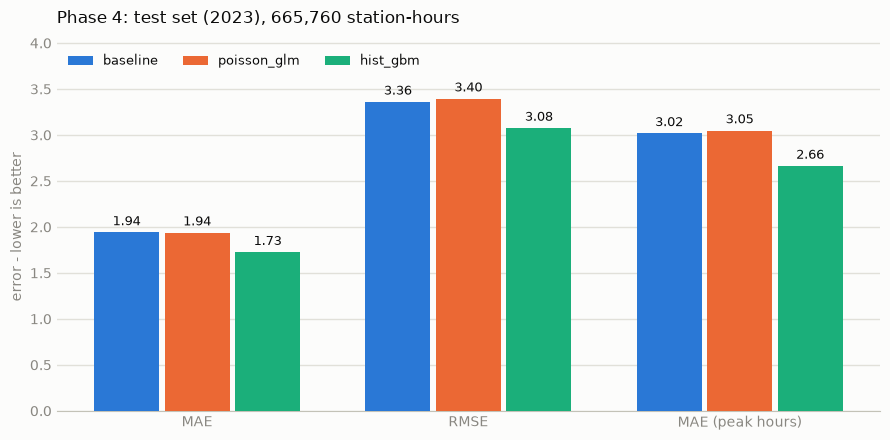

In [10]:
import matplotlib.pyplot as plt

# Validated categorical slots 1-3 (blue / orange / aqua).
COLORS = {"baseline": "#2a78d6", "poisson_glm": "#eb6834", "hist_gbm": "#1baf7a"}
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

metrics = ["MAE", "RMSE", "MAE_peak"]
models = list(comparison.index)
x = np.arange(len(metrics))
width = 0.26

fig, ax = plt.subplots(figsize=(9, 4.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

for i, m in enumerate(models):
    offset = (i - 1) * width
    vals = [comparison.loc[m, k] for k in metrics]
    bars = ax.bar(x + offset, vals, width * 0.92, label=m, color=COLORS[m], zorder=3)
    # aqua sits below 3:1 on this surface, so every bar carries a visible label
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9, color=INK)

ax.set_xticks(x, ["MAE", "RMSE", "MAE (peak hours)"], fontsize=10, color=INK)
ax.set_ylabel("error - lower is better", fontsize=10, color=MUTED)
ax.set_title("Phase 4: test set (2023), 665,760 station-hours",
             fontsize=12, color=INK, pad=14, loc="left")

ax.yaxis.grid(True, color=GRID, linewidth=1, zorder=0)
ax.set_axisbelow(True)
ax.set_ylim(0, comparison[metrics].to_numpy().max() * 1.18)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(axis="both", length=0, colors=MUTED)

ax.legend(frameon=False, ncols=3, loc="upper left",
          bbox_to_anchor=(0, 1.0), fontsize=9, labelcolor=INK)

fig.tight_layout()
fig.savefig("/tmp/phase4-comparison.png", dpi=140, facecolor=fig.get_facecolor())
plt.show()

## Step 8 - Persist the split

The model is chosen, so the split that chose it is now fixed. Writing it to
`data/split` means Phases 5-6 load the exact same rows instead of re-deriving
them - v1 and v2 are only comparable if they saw identical data.

It also pins the feature list: anything not in `FEATURES + [TARGET, "hour"]` is
dropped here, so a downstream notebook cannot accidentally train on `year` or
`start_date`. (`hour` is kept because peak-hour scoring needs it.)

In [11]:
import json

SPLIT = ML / "split"
SPLIT.mkdir(parents=True, exist_ok=True)

# start_date is carried for the leakage assertions downstream, not as a feature.
KEEP = FEATURES + [TARGET, "start_date"]

for name, df in [("train", train), ("val", val), ("test", test)]:
    df[KEEP].to_parquet(SPLIT / f"{name}.parquet", index=False)
    print(f"{name:6} {len(df):>9,} rows -> {name}.parquet")

# The contract downstream reads instead of hard-coding it.
(SPLIT / "split.json").write_text(json.dumps({
    "target": TARGET,
    "features": FEATURES,
    "categorical": CATEGORICAL,
    "numeric": NUMERIC,
    "peak_hours": PEAK_HOURS,
    "train_years": TRAIN_YEARS,
    "val_years": VAL_YEARS,
    "test_years": TEST_YEARS,
    "selected_model": "hist_gbm",
    "baseline_test_MAE": baseline_scores["MAE"],
}, indent=2))

print(f"\nwrote -> {SPLIT}")

train  1,999,104 rows -> train.parquet


val      611,040 rows -> val.parquet


test     665,760 rows -> test.parquet

wrote -> /opt/data/ml/split


In [12]:
# Read back and re-check the split boundaries on what actually landed on disk.
loaded = {
    name: pd.read_parquet(SPLIT / f"{name}.parquet")
    for name in ("train", "val", "test")
}

for name, df in loaded.items():
    src = {"train": train, "val": val, "test": test}[name]
    assert len(df) == len(src), f"{name} row count changed"
    assert df[TARGET].sum() == src[TARGET].sum(), f"{name} target changed"

assert loaded["train"]["start_date"].max() < loaded["val"]["start_date"].min()
assert loaded["val"]["start_date"].max() < loaded["test"]["start_date"].min()
assert not (set(FEATURES) & BANNED), "banned column in the persisted feature list"

pd.DataFrame([
    {"split": n, "rows": len(d), "trips": int(d[TARGET].sum()),
     "from": d["start_date"].min().date(), "to": d["start_date"].max().date()}
    for n, d in loaded.items()
]).set_index("split")

,rows,trips,from,to
split,,,,
train,1999104,2963480,2019-01-01,2021-12-31
val,611040,1291833,2022-01-01,2022-12-31
test,665760,1635517,2023-01-01,2023-12-31
